# 01_filter_exact_dates

## Visualize Temporal Resolution in raw Bleaching Database
### Only bleaching reports with exact dates (day/month/year) will be used since they need to be matched with the right daily heat stress metric value

#### Import libraries

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

#### Import raw database

In [2]:
# Go up one level from notebooks/ to 01_data_assembly/
root = Path("..")
file_path = root / "data" / "raw" / "Bleaching Database V2 - Urcelay and Donner.xlsx"
df = pd.read_excel(file_path)

#### Classify Date Resolution and Clean Year Column

This section categorizes each record based on the most precise date information available:
- "Exact date" if a full date is present
- "Month + Year" if only month and year are available
- "Year only" if only the year is present
- "Missing" if no date information exists

In [5]:
def classify_date(row):
    if pd.notnull(row.get('DATE')):
        return 'Exact date'
    elif pd.notnull(row.get('MONTH')):
        return 'Month + Year'
    elif pd.notnull(row.get('YEAR')):
        return 'Year only'
    else:
        return 'Missing'

df['resolution'] = df.apply(classify_date, axis=1)
df['YEAR'] = pd.to_numeric(df['YEAR'], errors='coerce')

In [6]:
df['resolution'].value_counts(dropna=False)

resolution
Exact date      21027
Month + Year    16030
Year only         717
Name: count, dtype: int64

#### Visualizing Date Resolution Distribution

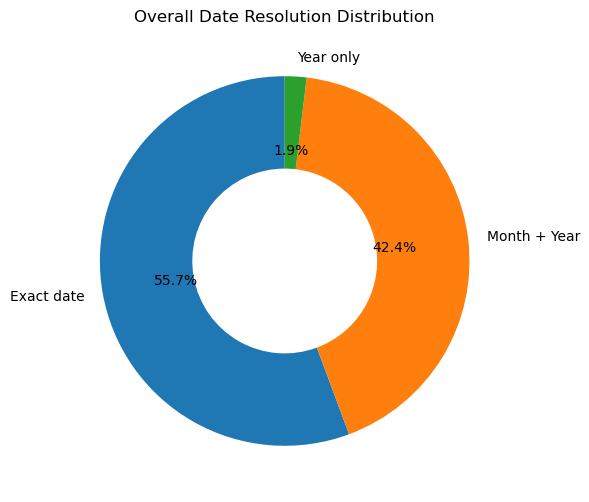

In [7]:
resolution_counts = df['resolution'].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 6))
resolution_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, wedgeprops=dict(width=0.5))
plt.title("Overall Date Resolution Distribution")
plt.ylabel('')
plt.show()

#### Date Resolution Trends Over Time
This visualization helps identify trends, such as whether more recent records have more precise date information.

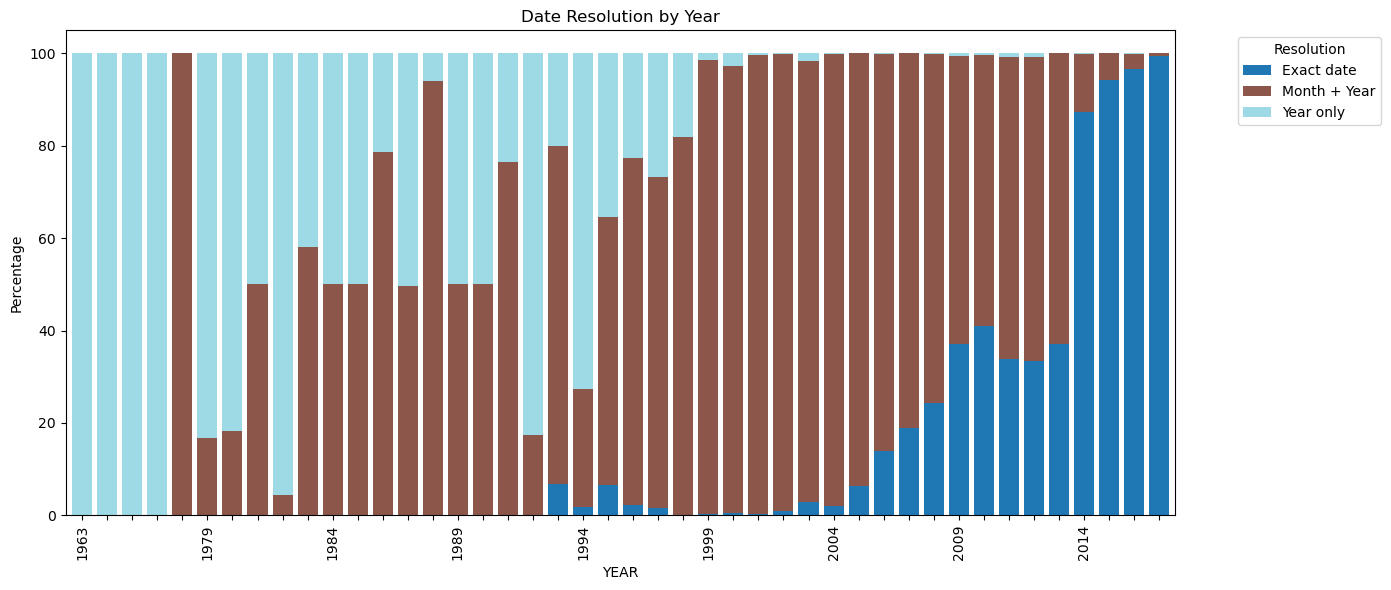

In [8]:
resolution_by_year = df.groupby(['YEAR', 'resolution']).size().unstack(fill_value=0)
resolution_by_year_percent = resolution_by_year.div(resolution_by_year.sum(axis=1), axis=0) * 100

plt.figure(figsize=(14, 6))
ax = resolution_by_year_percent.plot(kind='bar', stacked=True, colormap='tab20', width=0.8, legend=True, ax=plt.gca())

ticks_to_show = resolution_by_year_percent.index[::5]
ax.set_xticks(range(len(resolution_by_year_percent.index)))
ax.set_xticklabels(resolution_by_year_percent.index, rotation=90)
for i, label in enumerate(ax.get_xticklabels()):
    if resolution_by_year_percent.index[i] not in ticks_to_show:
        label.set_visible(False)

plt.ylabel("Percentage")
plt.title("Date Resolution by Year")
plt.legend(title='Resolution', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### Distribution of Exact Date Records by Year
The resulting bar chart shows how exact date records are distributed over time and highlights any gaps or concentration in specific years.

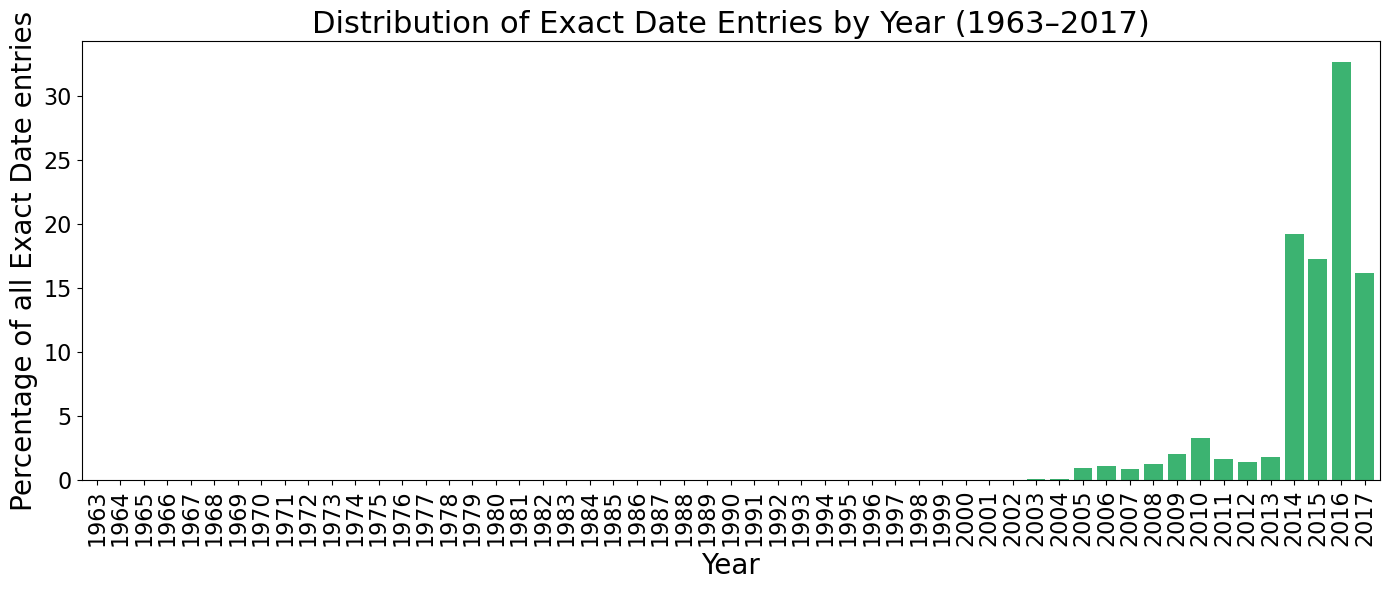

In [9]:
exact_df = df[df['resolution'] == 'Exact date']

exact_counts = exact_df['YEAR'].value_counts().sort_index()

min_year = int(df['YEAR'].min())
max_year = int(df['YEAR'].max())

all_years = pd.Series(index=range(min_year, max_year + 1), dtype=float)

exact_counts_full = all_years.fillna(0).add(exact_counts, fill_value=0)
exact_percentages = (exact_counts_full / exact_counts_full.sum()) * 100

plt.figure(figsize=(14, 6))
exact_percentages.plot(kind='bar', color='mediumseagreen', width=0.8)

plt.ylabel("Percentage of all Exact Date entries", fontsize=20)
plt.xlabel("Year", fontsize=20)
plt.title(f"Distribution of Exact Date Entries by Year ({min_year}–{max_year})", fontsize=22)

plt.xticks(rotation=90, fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.show()

#### Distribution of Exact Date Records by Ocean Region
This helps identify whether certain regions have a higher concentration of precise date records.

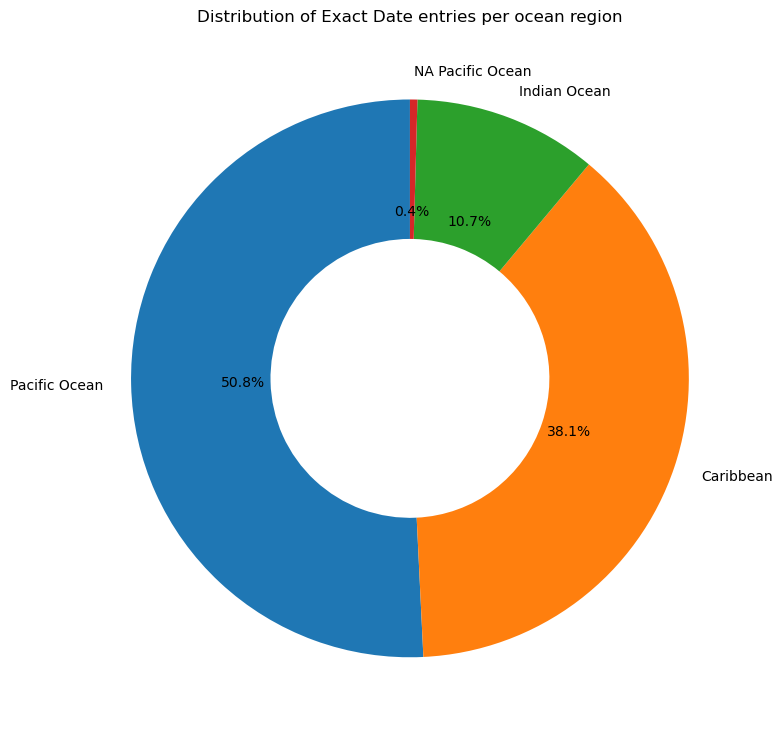

In [10]:
exact_df = df[df['resolution'] == 'Exact date']
region_counts = exact_df['OCEAN_REGION'].value_counts(normalize=True) * 100

plt.figure(figsize=(8, 8))
region_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.5),
    ylabel=''
)
plt.title("Distribution of Exact Date entries per ocean region")
plt.tight_layout()
plt.show()

#### Distribution of Exact Date Records by Severity Category
This visualization helps identify whether certain severity levels are more likely to have precise date information.

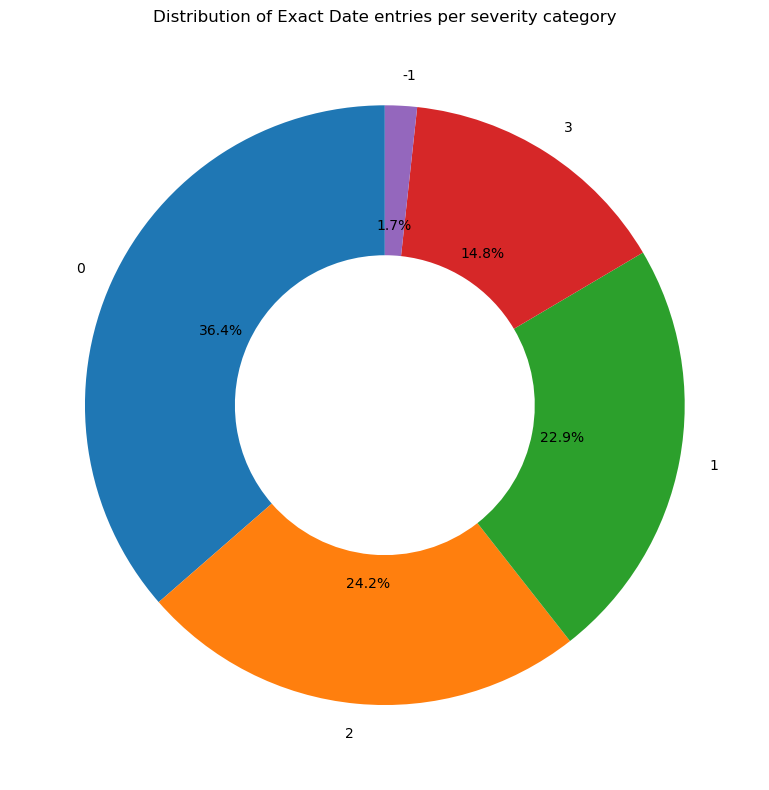

In [11]:
exact_df = df[df['resolution'] == 'Exact date']
severity_counts = exact_df['SEVERITY_CODE'].value_counts(normalize=True) * 100

plt.figure(figsize=(8, 8))
severity_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.5),
    ylabel=''
)
plt.title("Distribution of Exact Date entries per severity category")
plt.tight_layout()
plt.show()